In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import skyfield
from skyfield.api import Star, load, wgs84
from skyfield.data import hipparcos
from skyfield.timelib import Time

In [8]:
def get_limiting_magnitude(target_lat, target_lon, csv_path='GaN2024.csv'):
    df = pd.read_csv(csv_path) 
    df = df.dropna(subset=['SQMReading', 'Latitude', 'Longitude'])
    df = df[df['SQMReading'] > 15]
    df = df[df['SQMReading'] < 23]
    df['distance'] = np.sqrt(
        (df['Latitude'] - target_lat)**2 + 
        (df['Longitude'] - target_lon)**2
    )
    nearest_row = df.loc[df['distance'].idxmin()]
    print(f"Nearest data point is {nearest_row['distance']:.2f} degrees away.")
    print(f"Local Sky Brightness (SQM): {nearest_row['SQMReading']}")
    nelm = ((nearest_row['SQMReading'] - 8.89) / 2) + 0.5
    print(f"NELM: {nelm}")
    return nelm

def find_visible_stars(lat, lon, limiting_mag, time_input):
    with load.open(hipparcos.URL) as f:
        df_stars = hipparcos.load_dataframe(f)
    bright_stars = df_stars[df_stars['magnitude'] <= limiting_mag]
    ts = load.timescale()
    t = ts.utc(*time_input)
    planets = load('de421.bsp')
    earth = planets['earth']
    observer = earth + wgs84.latlon(latitude_degrees=lat, longitude_degrees=lon)
    stars = Star.from_dataframe(bright_stars)
    astrometric = observer.at(t).observe(stars)
    alt, az, distance = astrometric.apparent().altaz()
    visible_mask = alt.degrees > 0
    visible_stars = bright_stars[visible_mask]
    return visible_stars[['magnitude', 'ra_degrees', 'dec_degrees']]

Nearest data point is 0.54 degrees away.
Local Sky Brightness (SQM): 15.59
NELM: 3.8499999999999996


[Text(0.5, 1.0, 'The Night Sky'),
 Text(0.5, 0, 'Right ascension (h)'),
 Text(0, 0.5, 'Declination (°)')]

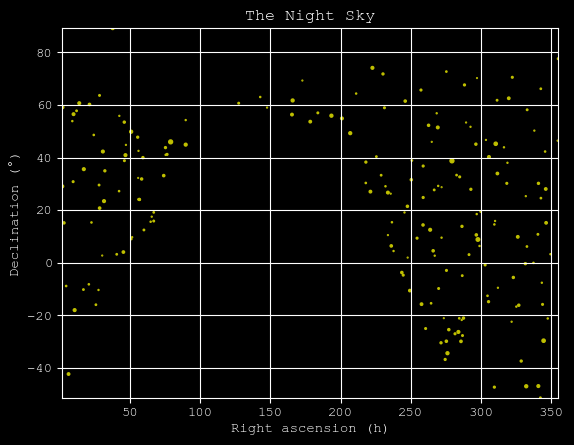

In [12]:
latitude = 34.0967
longitude = -117.7198
time = (2025, 12, 1, 1, 0, 0)
nelm = get_limiting_magnitude(latitude, longitude,'GaN2024.csv')
visible_stars = find_visible_stars(latitude, longitude, nelm, time)


fig, ax = plt.subplots()
plt.style.use("dark_background")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Courier New']
ax.scatter(visible_stars['ra_degrees'], visible_stars['dec_degrees'], 8 - (visible_stars['magnitude']) * 2, 'y')
ax.set_xlim(visible_stars['ra_degrees'].min(), visible_stars['ra_degrees'].max())
ax.set_ylim(visible_stars['dec_degrees'].min(), visible_stars['dec_degrees'].max())
ax.grid(True)
ax.set(title='The Night Sky',
       xlabel='Right ascension (h)', ylabel='Declination (°)')

This graph is the same as the rectangular one just plotted on a polar axis. The blank space represents the stars below the horizon. In oder to only show the stars one would see from earth, we need to use the altitude, azimuth system instead of RA, declination.


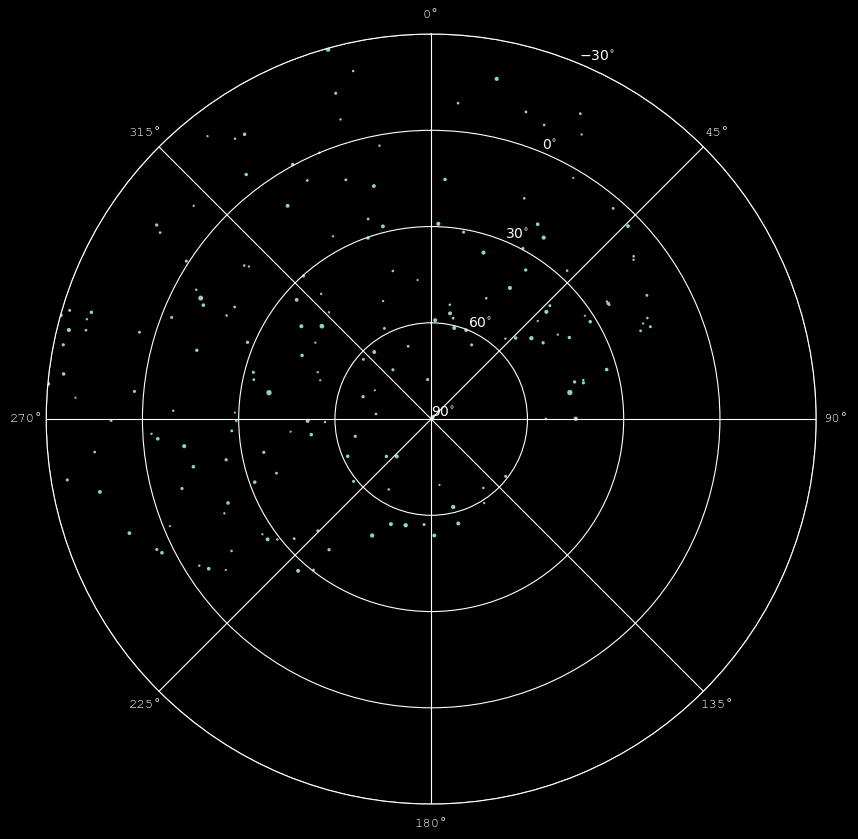

In [13]:
# convert ra, dec to polar coordinates
theta = np.deg2rad(visible_stars['ra_degrees'])
radius = 90 - visible_stars['dec_degrees'] # radius is 0 at declination = 90

fig, ax = plt.subplots(figsize = (10, 10), subplot_kw = {'projection': 'polar'})
plt.scatter(theta, radius,  8 - (visible_stars['magnitude']) * 2)

ax.set_ylim(0, 120) 
ax.set_theta_zero_location("N") # RA=0 at the top
ax.set_theta_direction(-1) # RA increases clockwise

r_ticks = [0, 30, 60, 90, 120]
dec_labels = ['$90^{\circ}$', '$60^{\circ}$', '$30^{\circ}$', '$0^{\circ}$', '$-30^{\circ}$']
ax.set_yticks(r_ticks) 
ax.set_yticklabels(dec_labels)

print(f'This graph is the same as the rectangular one just plotted on a polar axis. The blank space represents the stars below the horizon. In oder to only show the stars one would see from earth, we need to use the altitude, azimuth system instead of RA, declination.') 

In [14]:
# Converting from RA, Dec to alt, az
df = pd.read_csv("GaN2024.csv")
eph = load("de421.bsp")
earth = eph['earth']
observer = wgs84.latlon(latitude_degrees = 40.7128, longitude_degrees = -74.0060, elevation_m=0)
ts = load.timescale()
t = ts.now()

if 'epoch_year' not in df.columns:
    df['epoch_year'] = 2024.0

stars = Star.from_dataframe(df)

astrometric = (earth + observer).at(t).observe(stars)
apparent = astrometric.apparent()
alt, az, distance = apparent.altaz()

# Add alt, az to the old data frame
df['altitude_degrees'] = alt.degrees
df['azimuth_degrees'] = az.degrees
visible_stars_local = df[df['altitude_degrees'] >= 0].copy()
print(f"Number of stars visible above the horizon: {len(visible_stars_local)}")

KeyError: 'ra_hours'

In [15]:
theta = np.deg2rad(visible_stars_local['azimuth_degrees'])
r = 90 - visible_stars_local['altitude_degrees']


plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

ax.scatter(theta, r, 30 - (visible_stars_local['magnitude']) * 7.6, color='y', alpha=0.8)

ax.set_ylim(0, 90)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
r_ticks = [0, 30, 60, 90]

alt_labels = ['Zenith', '$60^{\circ}$', '$30^{\circ}$', '$0^{\circ}$ (Horizon)']
ax.set_yticks(r_ticks) 
ax.set_yticklabels(alt_labels, color = 'white')

az_labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
az_ticks = np.deg2rad(np.arange(0, 360, 45))
ax.set_xticks(az_ticks)
ax.set_xticklabels(az_labels, color='white')

ax.set_title('Local Night Sky View (Azimuth/Altitude Plot)', color='white', pad=15)
ax.grid(True, alpha=0.5)

plt.show()

NameError: name 'visible_stars_local' is not defined